In [5]:
%pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl (7.2 MB)
U


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

# Reading in the data
df = pd.read_csv(r'C:\Users\Adjetey\Desktop\analysis with python\scripts\movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Data Cleaning Phase
Before analyzing the relationship between movie budgets and gross revenue, we must ensure the data is consistent and complete.

### Steps taken in this section:
1. Handling Missing Values: Checking for `NaN` values across all columns.
2. Data Type Conversion: Converting `budget`, `gross`, and `votes` from floats to `int64` for better readability.
3. Correcting Release Years: Extracting the "Actual" release year from the `released` string using Regex, as it often differs from the `year` column.
4. Dropping Duplicates: Ensuring each movie entry is unique.

In [2]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [ ]:

print(df.isnull().sum())

print(df.isnull().mean() * 100)

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64
name         0.000000
rating       1.004173
genre        0.000000
year         0.000000
released     0.026082
score        0.039124
votes        0.039124
director     0.000000
writer       0.039124
star         0.013041
country      0.039124
budget      28.312467
gross        2.464789
company      0.221701
runtime      0.052165
dtype: float64


In [4]:
# Looking up the Data Type of each column

print(df.dtypes)

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes       float64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime     float64
dtype: object


In [5]:
# dropping null rows and changing data type of column

df = df.dropna()
df['votes'] = df['votes'].astype('int64')

In [33]:
# Creating correct year of release column

df['year of release'] = df['released'].str.extract(r'(\d{4})')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year of release
3203,Trojan War,PG-13,Comedy,1997,"October 1, 1997 (Brazil)",5.7,5800,George Huang,Andy Burg,Will Friedle,United States,15000000.0,309.0,Daybreak,85.0,1997
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000.0,2270.0,Embassy Pictures,85.0,1982
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000.0,2554.0,Copperheart Entertainment,108.0,2001
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000.0,2970.0,Trimark Pictures,97.0,1994
5640,Tanner Hall,R,Drama,2009,"January 15, 2015 (Sweden)",5.8,3500,Francesca Gregorini,Tatiana von Fürstenberg,Rooney Mara,United States,3000000.0,5073.0,Two Prong Lesson,96.0,2015


In [34]:
df = df.sort_values(by=['gross'], inplace=False, ascending=True)

In [36]:
df.drop_duplicates()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year of release
3203,Trojan War,PG-13,Comedy,1997,"October 1, 1997 (Brazil)",5.7,5800,George Huang,Andy Burg,Will Friedle,United States,15000000.0,3.090000e+02,Daybreak,85.0,1997
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000.0,2.270000e+03,Embassy Pictures,85.0,1982
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000.0,2.554000e+03,Copperheart Entertainment,108.0,2001
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000.0,2.970000e+03,Trimark Pictures,97.0,1994
5640,Tanner Hall,R,Drama,2009,"January 15, 2015 (Sweden)",5.8,3500,Francesca Gregorini,Tatiana von Fürstenberg,Rooney Mara,United States,3000000.0,5.073000e+03,Two Prong Lesson,96.0,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000.0,2.048360e+09,Marvel Studios,149.0,2018
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000.0,2.069522e+09,Lucasfilm,138.0,2015
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000.0,2.201647e+09,Twentieth Century Fox,194.0,1997
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000.0,2.797501e+09,Marvel Studios,181.0,2019


Text(0, 0.5, 'Budget for Film')

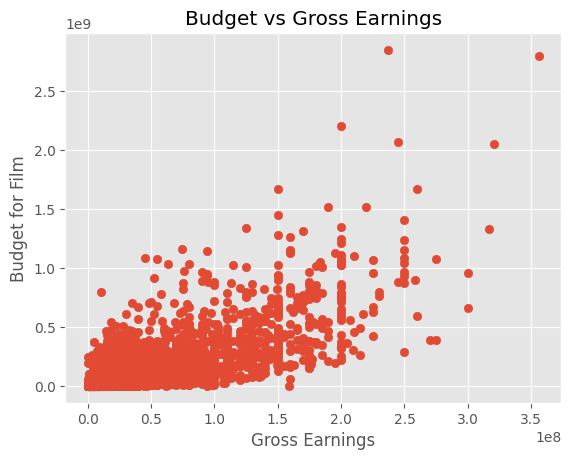

In [30]:
# budget vs gross Scatter ploat

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget for Film')




In [31]:
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year of release
3203,Trojan War,PG-13,Comedy,1997,"October 1, 1997 (Brazil)",5.7,5800,George Huang,Andy Burg,Will Friedle,United States,15000000.0,309.0,Daybreak,85.0,1997
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000.0,2270.0,Embassy Pictures,85.0,1982
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000.0,2554.0,Copperheart Entertainment,108.0,2001
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000.0,2970.0,Trimark Pictures,97.0,1994
5640,Tanner Hall,R,Drama,2009,"January 15, 2015 (Sweden)",5.8,3500,Francesca Gregorini,Tatiana von Fürstenberg,Rooney Mara,United States,3000000.0,5073.0,Two Prong Lesson,96.0,2015


<Axes: xlabel='budget', ylabel='gross'>

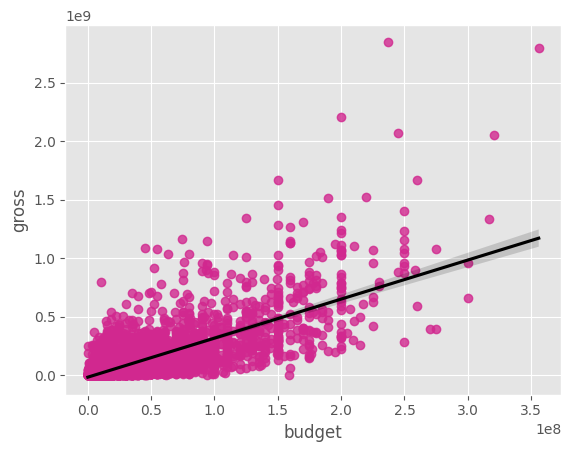

In [28]:
# plot budget vs gross using seaborn

sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color": "#d1288f"}, line_kws={"color": "#000"})

## Correlation Matrix

In [14]:
# 
df.corr(numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.056386,0.206021,0.327722,0.274321,0.075077
score,0.056386,1.000000,0.474256,0.072001,0.222556,0.414068
votes,0.206021,0.474256,1.000000,0.439675,0.614751,0.352303
budget,0.327722,0.072001,0.439675,1.000000,0.740247,0.318695
gross,0.274321,0.222556,0.614751,0.740247,1.000000,0.275796
runtime,0.075077,0.414068,0.352303,0.318695,0.275796,1.000000


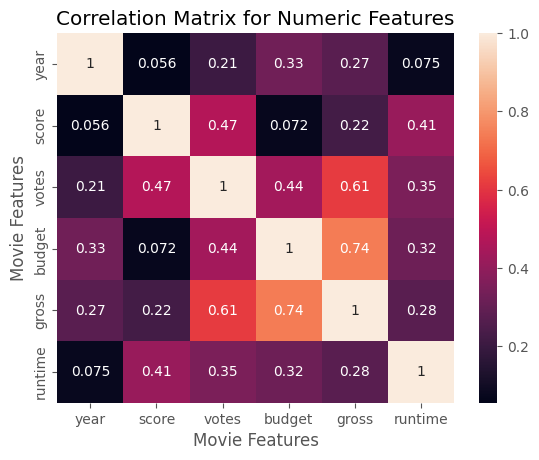

In [15]:
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)

plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

OBSERVATIONS

1. Budget vs. Gross
    There's a big correlation between budget and gross. It can therefore be concluded that, the more money a studio spends, the more money they make at the box office.

2. Votes vs. Gross
    This is a moderate correlation which stands at 0.61. It shows that movies with more public engagement tends to have higher gross revenue. The popular the movie is , the more money it generates.

3. Score vs. Gross
    The correlation between these variables stands at 0.22. This suggests just because a movies is good doesn't necessarily converts to more money the studio will make.



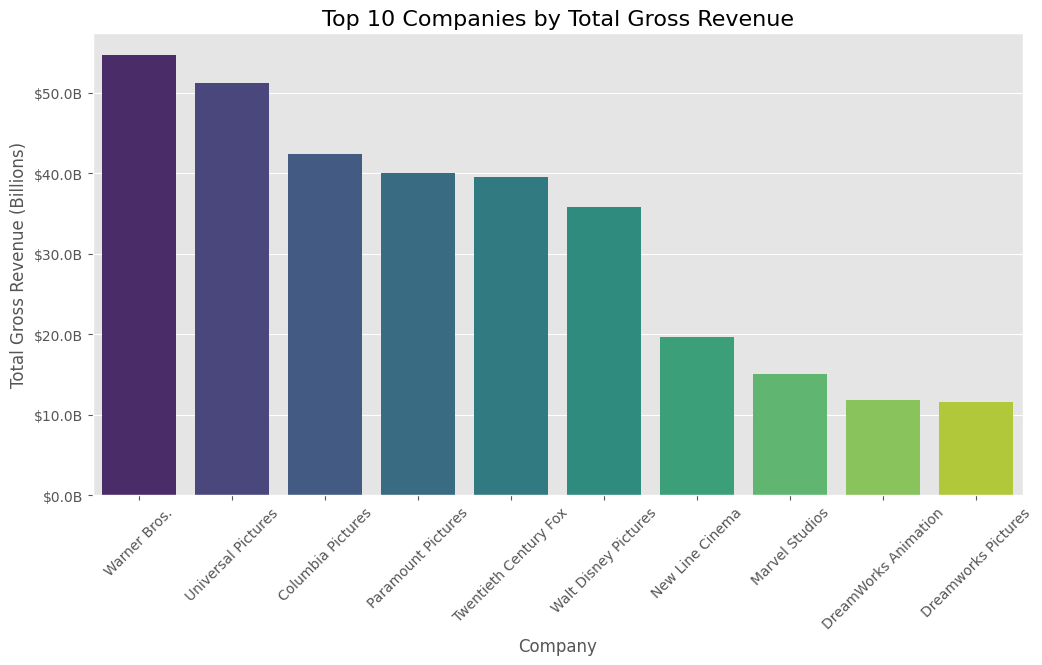

In [16]:

CompanyGrossSum = df.groupby('company')[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values(by='gross', ascending=False)[:10]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=CompanyGrossSumSorted.index, 
    y=CompanyGrossSumSorted['gross'], 
    hue=CompanyGrossSumSorted.index, 
    palette='viridis'                
)

plt.title('Top 10 Companies by Total Gross Revenue', fontsize=16)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Total Gross Revenue (Billions)', fontsize=12)
plt.xticks(rotation=45) 


# Formatting Y-axis to Billions
from matplotlib.ticker import FuncFormatter
def billions(x, pos):
    return f'${x*1e-9:.1f}B'

formatter = FuncFormatter(billions)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

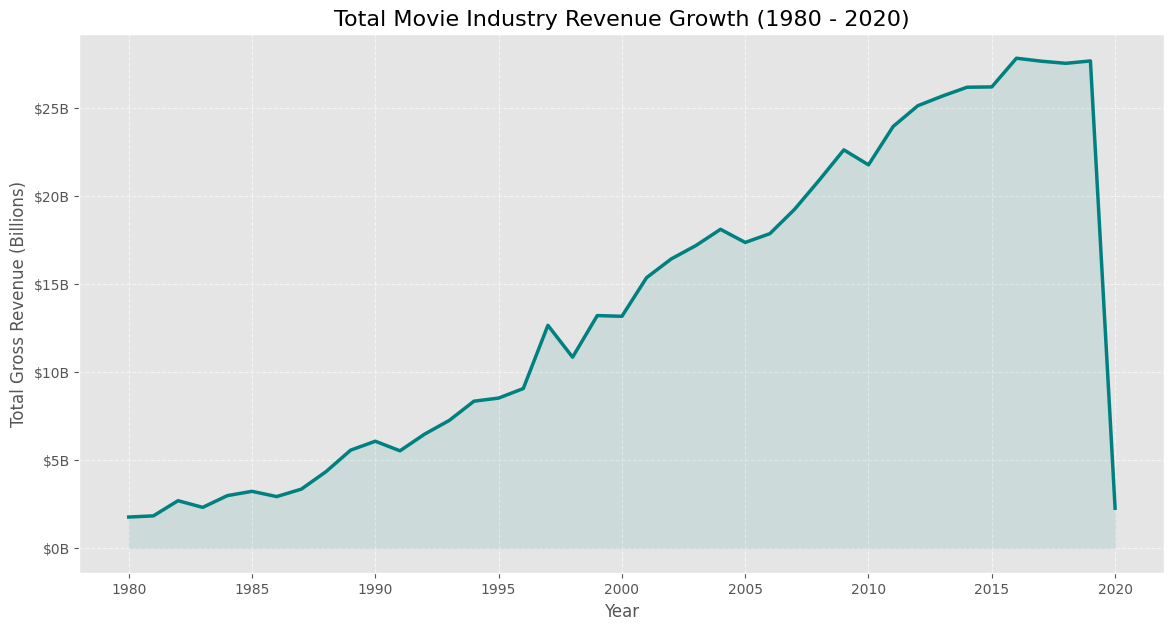

In [17]:

YearlyGross = df.groupby('year')[["gross"]].sum()

plt.figure(figsize=(14, 7))
sns.lineplot(x=YearlyGross.index, y=YearlyGross['gross'], color='teal', linewidth=2.5)

plt.fill_between(YearlyGross.index, YearlyGross['gross'], color='teal', alpha=0.1)

plt.title('Total Movie Industry Revenue Growth (1980 - 2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Gross Revenue (Billions)', fontsize=12)

from matplotlib.ticker import FuncFormatter
def billions(x, pos):
    return f'${x*1e-9:.0f}B'

plt.gca().yaxis.set_major_formatter(FuncFormatter(billions))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

INSIGHTS FROM THE TREND

1. Steady Growth (1980-2016)
    There was a consistent climb decade over decade in gross revenue. This shows how resilient the industry is having gone through recessions without dipping.
    
2. Historic Peak (2017-2019)
    The industry reached its peak between 2017 and 2019. This era saw major frachises pushed annual revenues to record breaking heights.

3. The Dip (2020)
    The trend saw a sharp decline in 2020, reaching its lowest point in modern history. This is as a direct consequence of the COVID-19 Pandemic which force global shutdown of cinemas. It also caused the postponement of major blockbuster releases.

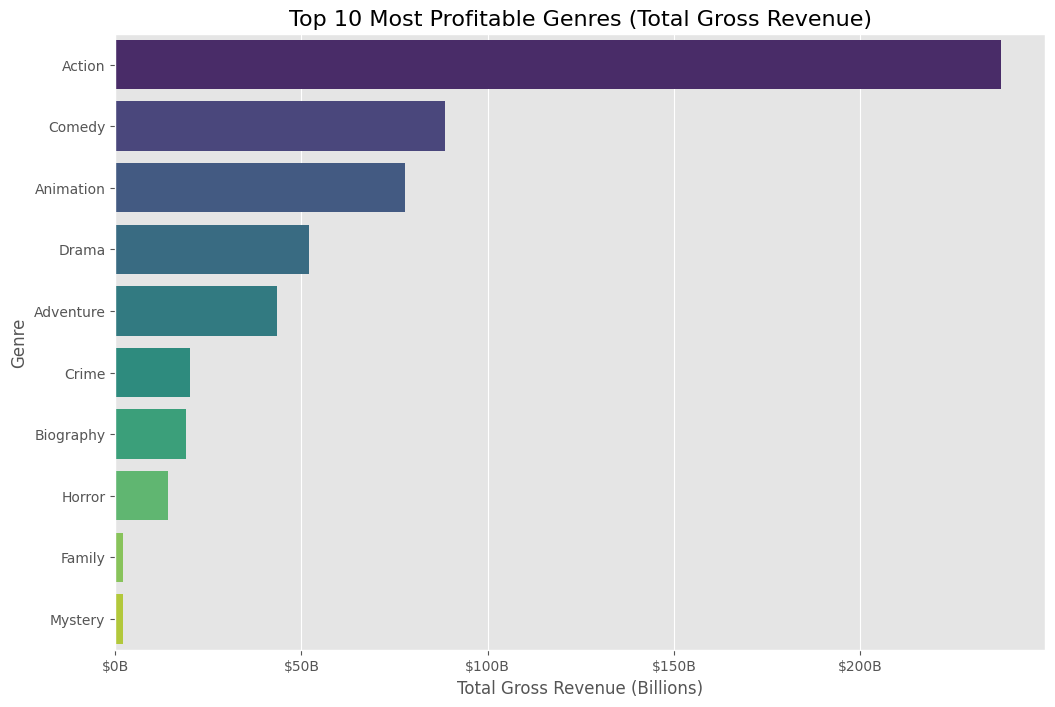

In [18]:
# Highest grossing genre

GenreGross = df.groupby('genre')[["gross"]].sum()

GenreGrossSorted = GenreGross.sort_values(by='gross', ascending=False).head(10)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=GenreGrossSorted['gross'], 
    y=GenreGrossSorted.index, 
    hue=GenreGrossSorted.index, 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Most Profitable Genres (Total Gross Revenue)', fontsize=16)
plt.xlabel('Total Gross Revenue (Billions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

from matplotlib.ticker import FuncFormatter
def billions(x, pos):
    return f'${x*1e-9:.0f}B'

plt.gca().xaxis.set_major_formatter(FuncFormatter(billions))

plt.show()

In [20]:
# Determining which genre has the highes ROI
GenreStats = df.groupby('genre')[['budget', 'gross']].sum()

GenreStats['ROI'] = GenreStats['gross'] / GenreStats['budget']

TopROIResults = GenreStats.sort_values(by='ROI', ascending=False).head(10)

print(TopROIResults)

                 budget         gross        ROI
genre                                           
Family     2.045000e+08  2.074333e+09  10.143436
Horror     3.372067e+09  1.426106e+10   4.229173
Mystery    5.419000e+08  2.004091e+09   3.698268
Animation  2.114157e+10  7.786591e+10   3.683071
Thriller   8.920000e+07  2.974170e+08   3.334271
Adventure  1.502856e+10  4.357871e+10   2.899726
Action     8.273301e+10  2.377529e+11   2.873736
Drama      2.005774e+10  5.209856e+10   2.597429
Comedy     3.411235e+10  8.851482e+10   2.594803
Biography  7.912359e+09  1.909393e+10   2.413178


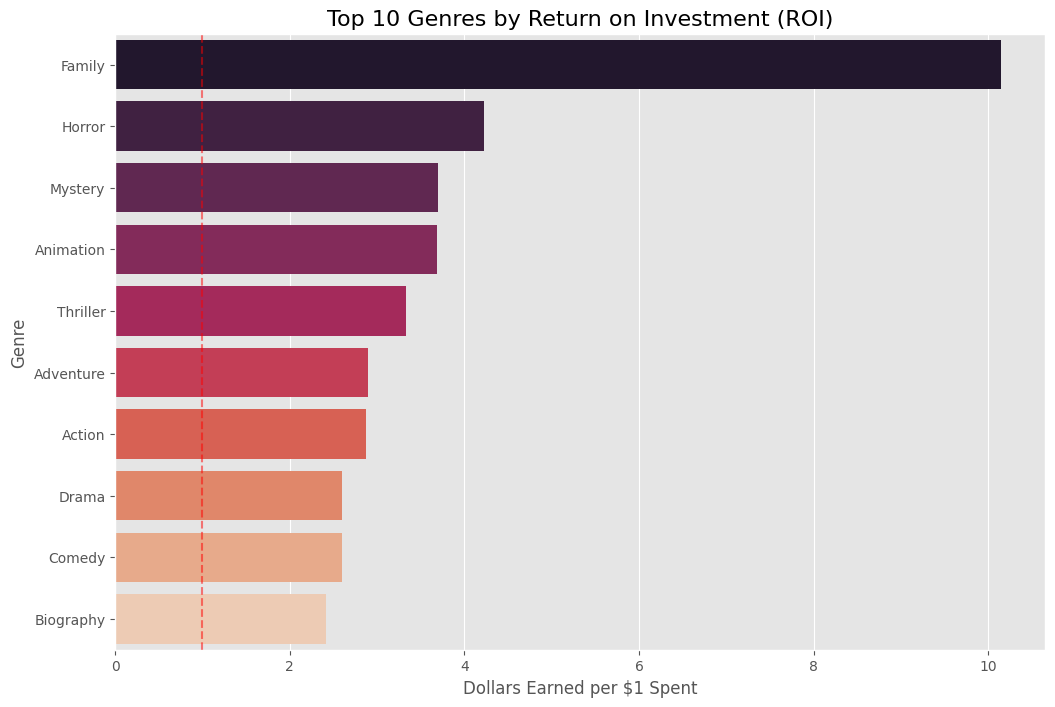

In [21]:
# Graphical representation of ROI

GenreStats = df.groupby('genre')[['budget', 'gross']].sum()

GenreStats['roi'] = GenreStats['gross'] / GenreStats['budget']

GenreROISorted = GenreStats.sort_values(by='roi', ascending=False).head(10)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=GenreROISorted['roi'], 
    y=GenreROISorted.index, 
    hue=GenreROISorted.index, 
    palette='rocket', 
    legend=False
)

plt.title('Top 10 Genres by Return on Investment (ROI)', fontsize=16)
plt.xlabel('Dollars Earned per $1 Spent', fontsize=12)
plt.ylabel('Genre', fontsize=12)

plt.axvline(1, color='red', linestyle='--', alpha=0.5, label='Break Even')

plt.show()

RETURN ON INVESTMENT

1. Family Genre
    Despite receiving lower budget allocation as compared to Action, it yeilds the highest ROI. 
    Movies in this genre typically enjoy repeat viewings while maintaining lower production costs that CGI action films.

2. Action Genre
    Though they claim the highest total grossing figures, they rank among the lowest in ROI.
    To achieve record breaking gross figures, studios spend a lot on poduction and marketing. 
    Actions movies generate massive cash flow but operate on thinner profit margins than Family movies.

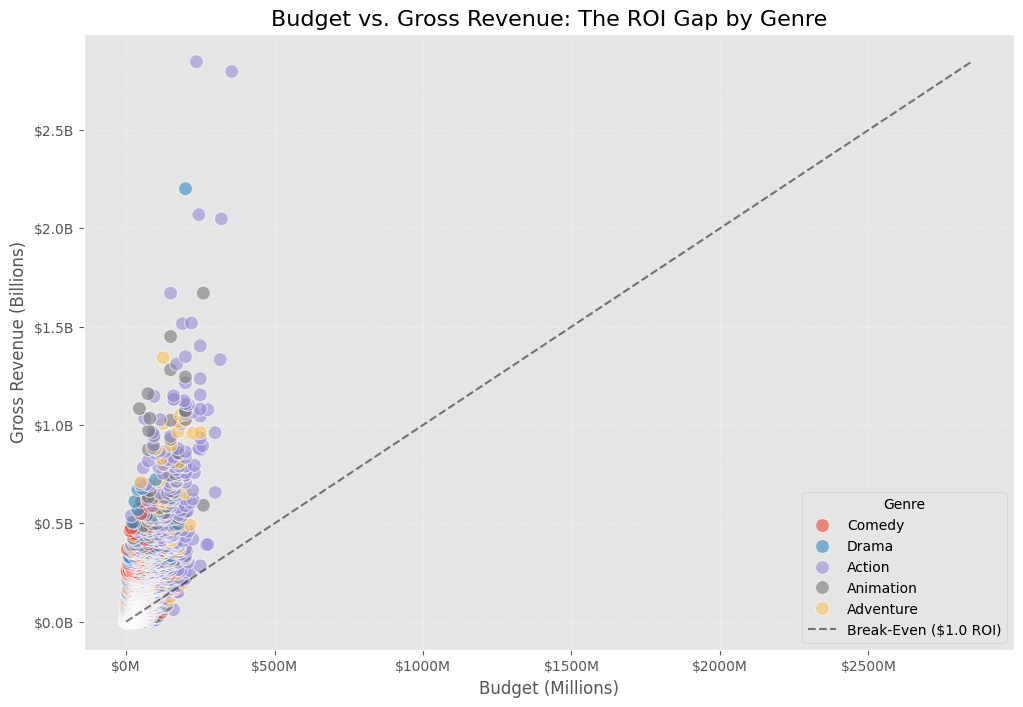

In [23]:
# 1. Filter for the Top 5-10 Genres to keep the plot clean
top_genres = df.groupby('genre')['gross'].sum().sort_values(ascending=False).head(5).index
df_filtered = df[df['genre'].isin(top_genres)]

# 2. Create the Scatter Plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_filtered, 
    x='budget', 
    y='gross', 
    hue='genre', 
    alpha=0.6, 
    s=100
)

# 3. Add a "Break-Even" Line (where Gross = Budget)
# Any dot ABOVE this line made a profit. Any dot BELOW it lost money.
lims = [0, max(df_filtered['budget'].max(), df_filtered['gross'].max())]
plt.plot(lims, lims, 'k--', alpha=0.5, label='Break-Even ($1.0 ROI)')

# 4. Formatting
plt.title('Budget vs. Gross Revenue: The ROI Gap by Genre', fontsize=16)
plt.xlabel('Budget (Millions)', fontsize=12)
plt.ylabel('Gross Revenue (Billions)', fontsize=12)

# Use our Billions/Millions formatter
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x*1e-9:.1f}B'))
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x*1e-6:.0f}M'))

plt.legend(title='Genre')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Movie Industry Analysis: Final Executive Summary

OVERVIEW
This project analyzed a dataset of over 30 years of cinematic history to determine the primary drivers of financial success. After cleaning the data and removing missing values, we explored the relationships between Budget, Gross Revenue, Public Engagement (Votes), and Genre Efficiency.

KEY FINDINGS
1. The "Money Makes Money" Rule
    Our correlation analysis revealed a high positive correlation (0.75) between a movie's Budget and its Gross Revenue.

2. Conclusion: 
    High-budget "Tentpole" films remain the most reliable way for studios to generate massive cash flow. If a studio wants to hit the $1B mark, they almost certainly have to invest $150M+ upfront.

2. Popularity vs. Quality
    Votes vs. Gross (0.63): 
    There is a strong link between public engagement and revenue. Movies that generate "hype" and high vote counts on platforms like IMDb consistently outperform others.

    Score vs. Gross (0.19): 
    Interestingly, critical acclaim (Score) has a very weak relationship with financial success. A "good" movie does not guaranteed a "profitable" movie.

3. The Efficiency Paradox (Action vs. Family)
    By comparing total volume against Return on Investment (ROI), we discovered a strategic divide in Hollywood:

    Action & Sci-Fi: 
    These genres are the "Revenue Kings," contributing the most to total industry growth, but they have lower relative profit margins due to extreme production costs.

    Family & Animation: 
    These are the "Efficiency Champions." They consistently yield the highest ROI, proving that they are the most mathematically sound investment for a studio looking to multiply their capital with lower risk.

The "Black Swan" of 2020
    Our time-series analysis highlighted the industry's steady climb toward a historic peak in 2017–2019. However, the data shows a precipitous collapse in 2020. This anomaly is directly attributed to the COVID-19 pandemic, which disrupted a 40-year growth trend and forced the industry to pivot toward streaming models.

Strategic Recommendation
    For a studio looking to balance risk and reward, the data suggests a diversified portfolio:

    Invest in Family/Animation for high-margin, consistent returns.

    Invest in Action Blockbusters to maintain market share and high total cash flow.

    Ignore "Critics' Scores" as a predictor of financial ROI; focus instead on Marketing and Public Engagement (Votes).